# Imports

In [ ]:
import html
import json
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import re
import spacy
import time
import unicodedata

from deep_translator import GoogleTranslator
from langdetect import detect, DetectorFactory, LangDetectException
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from wordcloud import WordCloud

In [2]:
df1 = pd.read_csv('../csv/X_train_update.csv')
df2 = pd.read_csv('../csv/Y_train_CVw08PX.csv')

df_raw = pd.concat([df1, df2], axis=1)
df_raw = df_raw.drop(['Unnamed: 0'], axis=1)
df_raw["image_filename"] = "image_" + df_raw["imageid"].astype(str) + "_product_" + df_raw["productid"].astype(str) + ".jpg"

display(df_raw.info())
df_raw.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 84916 entries, 0 to 84915
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   designation     84916 non-null  str  
 1   description     55116 non-null  str  
 2   productid       84916 non-null  int64
 3   imageid         84916 non-null  int64
 4   prdtypecode     84916 non-null  int64
 5   image_filename  84916 non-null  str  
dtypes: int64(3), str(3)
memory usage: 56.2 MB


None

,designation,description,productid,imageid,prdtypecode,image_filename
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,10,image_1263597046_product_3804725264.jpg
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,2280,image_1008141237_product_436067568.jpg
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50,image_938777978_product_201115110.jpg
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496,1280,image_457047496_product_50418756.jpg
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,2705,image_1077757786_product_278535884.jpg


# Preprocessing

## Nettoyage du texte

In [3]:
# Copie du DataFrame original par sécurité avant de le modifier
df = df_raw.copy()

# Suppression des descriptions identiques à la désignation
#---------------------------------------------------------------------
df.loc[df['description'].str.lower().str.strip() == df['designation'].str.lower().str.strip() , 'description'] = np.nan

# Création d’une colonne booléenne “description_absente”
#---------------------------------------------------------------------
df['description_absente'] = df['description'].isna()

# Concaténation des colonnes designation et description
#---------------------------------------------------------------------
df["texte_complet"] = df["designation"].fillna("") + " " + df["description"].fillna("")
df["texte_complet"] = df["texte_complet"].astype(str).str.strip()

# Traitement des entités HTML
#---------------------------------------------------------------------
def ttt_html(x):
    x = html.unescape(x) 
    x = re.sub(r"<[^>]+>", " ", x)  
    return x

df["texte_complet"] = df["texte_complet"].apply(ttt_html)

# Suppression des caractères invisibles ou de contrôle 
#---------------------------------------------------------------------
inv_caract = re.compile(r"[\x00-\x1F\x7F-\x9F\u200B-\u200F\u2028\u2029\u2060\ufeff]")
df["texte_complet"] = df["texte_complet"].str.replace(inv_caract, " ", regex=True)

# Correction ciblée des problèmes d'encodage
# ---------------------------------------------------------------------
replacements = { "Ã©": "é",  "Ã¨": "è",  "Ãª": "ê",  "Ã ": "à", "Ã¢": "â", "Ã®": "î",  "Ã´": "ô",  "Ã¹": "ù",
        "Ã»": "û",  "Ã§": "ç",  "Â°": "°", "Â²": "²", "Â·": " ", "Â": "", "â€™": "'", "â€˜": "'", "â€œ": '"',
        "â€": '"', "â€“": "-", "â€”": "-", "â€¦": "..."}

def fix_encoding_issues(text):
    if pd.isna(text):
        return ""
    
    text = str(text)    
       
    for bad, good in replacements.items():
        text = text.replace(bad, good)
    
    return text

df["texte_complet"] = df["texte_complet"].apply(fix_encoding_issues)

# Normalisation Unicode
# ---------------------------------------------------------------------
df["texte_complet"] = df["texte_complet"].apply(lambda x: unicodedata.normalize("NFKC", str(x)))

# Conversion en minuscules
#---------------------------------------------------------------------
df["texte_complet"] = df["texte_complet"].str.lower()

# suppression des urls
#---------------------------------------------------------------------
df["texte_complet"] = df["texte_complet"].str.replace(r"http\S+|www\S+", " ", regex=True)

# Sauvegarde du texte avant suppression des stopwords et nettoyage des caractères spéciaux pour détection de la langue
#---------------------------------------------------------------------
df["texte_avant_stopwords"] = df["texte_complet"].copy()

# Suppression des stopwords français et anglais
#---------------------------------------------------------------------
stop_words_fr = set(stopwords.words("french"))
stop_words_en = set(stopwords.words("english"))

stop_words = stop_words_fr | stop_words_en

def remove_stopwords(text):
    if pd.isna(text):
        return ""
    tokens = str(text).split()
    tokens = [word for word in tokens if word.lower() not in stop_words]
    
    return " ".join(tokens)

df["texte_complet"] = df["texte_complet"].apply(remove_stopwords)

# Suppression des caractères spéciaux / unicodes / ponctuation / Numériques / tokens isolés d'une seule lettre
#---------------------------------------------------------------------
def clean_special_chars(text):
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # Normalisation Unicode : homogénéise les caractères équivalents
    text = unicodedata.normalize("NFKC", text)
    
    
    text = re.sub( r"[^a-zA-ZàâäçèéêëîïôöùûüÿñæœÀÂÄÇÈÉÊËÎÏÔÖÙÛÜŸÑÆŒ0-9\s]", " ",  text, flags=re.UNICODE)

    text = re.sub( r"\d+", " ",  text, flags=re.UNICODE)
    
    # Suppression des tokens isolés d'une seule lettre
    text = re.sub(r"\b[a-zA-Zàâäçèéêëîïôöùûüÿñæœ]\b", " ", text)
    
    # Suppression des tokens de deux lettres sauf "ps"
    text = re.sub(r"\b(?!(?:ps|pc)\b)[a-zA-Zàâäçèéêëîïôöùûüÿñæœ]{2}\b", " ",  text)
    return text

df["texte_complet"] = df["texte_complet"].apply(clean_special_chars)


# Suppression des espaces multiples
#---------------------------------------------------------------------
df["texte_complet"] = df["texte_complet"].str.replace(r"\s+", " ", regex=True).str.strip()

# Suppression des 4 lignes dont le texte complet est vide ou trop court
df = df[df["texte_complet"].str.len() >= 2]




## Détection de la langue 

In [4]:
DetectorFactory.seed = 0

def detect_lang(text):
    if not isinstance(text, str) or text.strip() == "":
        return "unknown"
    
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

df["langue"] = df["texte_avant_stopwords"].apply(detect_lang)

In [5]:
# Analyse de la répartition des langues détectées en % du dataset
print(f"Il y a {len(df['langue'].value_counts(normalize=True))} langues détectées dans le dataset.")

print("Répartition des langues :")  
df['langue'].value_counts(normalize=True)

Il y a 31 langues détectées dans le dataset.
Répartition des langues :


langue
fr    0.820402
en    0.106581
it    0.013838
ca    0.009739
es    0.005606
ro    0.005441
nl    0.004334
no    0.003592
de    0.003580
af    0.003533
da    0.003427
pt    0.002815
sv    0.002520
cy    0.002096
id    0.001708
et    0.001378
sl    0.001343
tl    0.001319
hr    0.001107
pl    0.000836
so    0.000742
fi    0.000695
sw    0.000636
sk    0.000589
sq    0.000459
cs    0.000459
lt    0.000377
lv    0.000294
hu    0.000271
tr    0.000188
vi    0.000094
Name: proportion, dtype: float64

## Traduction des lignes non françaises

In [13]:


# Chemins de sauvegarde
CACHE_PATH = Path("../csv/traductions_en_fr_cache.json")
OUTPUT_PATH = Path("../csv/X_train_update_translated.csv")
CHECKPOINT_PATH = Path("../csv/X_train_update_translated_checkpoint.csv")

# Sauvegarde du texte avant traduction
df["texte_avant_traduction"] = df["texte_complet"].copy()

# Sécurisation du texte
texte = df["texte_complet"].fillna("").astype(str).str.strip()

# On traduit seulement les textes anglais, non vides, et de plus de 15 caractères
a_traduire = ((df["langue"] == "en") & texte.ne("") & (texte.str.len() > 15))

print(f"Lignes à traduire : {a_traduire.sum()}")

# Textes uniques à traduire
textes_uniques = texte.loc[a_traduire].drop_duplicates().tolist()

print(f"Textes uniques à traduire : {len(textes_uniques)}")

# Chargement du cache si déjà existant
if CACHE_PATH.exists():
    with open(CACHE_PATH, "r", encoding="utf-8") as f:
        traductions = json.load(f)
    print(f"Traductions déjà en cache : {len(traductions)}")
else:
    traductions = {}

# On ne traduit que ce qui n'est pas déjà dans le cache
textes_restants = [t for t in textes_uniques if t not in traductions]

print(f"Textes restants à traduire : {len(textes_restants)}")

translator = GoogleTranslator(source="en", target="fr")

def save_cache():
    with open(CACHE_PATH, "w", encoding="utf-8") as f:
        json.dump(traductions, f, ensure_ascii=False)

def translate_to_fr(text, max_retries=3):
    text = str(text).strip()

    if text == "":
        return text

    # Limite de sécurité Google Translate
    text_cut = text[:4500]

    for tentative in range(max_retries):
        try:
            return translator.translate(text_cut)
        except Exception as e:
            print(f"Échec traduction tentative {tentative + 1}/{max_retries} :", e)
            time.sleep(2 ** tentative)

    # Si toutes les tentatives échouent, on garde le texte original
    return text

for i, text in enumerate(tqdm(textes_restants, desc="Traduction"), start=1):
    traductions[text] = translate_to_fr(text)

    # Sauvegarde du cache toutes les 100 traductions
    if i % 100 == 0:
        save_cache()

    # Checkpoint CSV toutes les 500 traductions
    if i % 500 == 0:
        df_temp = df.copy()
        texte_temp = df_temp["texte_complet"].fillna("").astype(str).str.strip()

        df_temp.loc[a_traduire, "texte_complet"] = (
            texte_temp.loc[a_traduire]
            .map(traductions)
            .fillna(df_temp.loc[a_traduire, "texte_complet"])
        )

        df_temp.to_csv(CHECKPOINT_PATH, index=False)
        print(f"Checkpoint sauvegardé après {i} traductions.")

# Sauvegarde finale du cache
save_cache()

# Application finale des traductions au dataframe
df.loc[a_traduire, "texte_complet"] = (
    texte.loc[a_traduire]
    .map(traductions)
    .fillna(df.loc[a_traduire, "texte_complet"])
)

print("Traduction terminée.")

df.to_csv(OUTPUT_PATH, index=False)

Lignes à traduire : 8831
Textes uniques à traduire : 8614
Textes restants à traduire : 8614


Traduction:   6%|▌         | 500/8614 [03:47<3:36:44,  1.60s/it]

Checkpoint sauvegardé après 500 traductions.


Traduction:  12%|█▏        | 1000/8614 [07:36<3:23:45,  1.61s/it]

Checkpoint sauvegardé après 1000 traductions.


...

Checkpoint sauvegardé après 8000 traductions.


Traduction:  99%|█████████▊| 8500/8614 [2:02:38<03:50,  2.02s/it]

Checkpoint sauvegardé après 8500 traductions.


Traduction: 100%|██████████| 8614/8614 [2:04:44<00:00,  1.15it/s]


Traduction terminée.


In [18]:
df.loc[df["langue"] == "en", ["texte_avant_traduction", "texte_complet"]].head(20)

,texte_avant_traduction,texte_complet
10,eames inspired sxw chair pink black timeless d...,chaise eames inspirée sxw rose noir intemporel...
12,peaceable kingdom wheres bear hide find stacki...,royaume paisible où se cache l'ours trouver un...
17,mod podge dishwasher safe gloss,mod podge brillant lavable au lave-vaisselle
18,power rangers rouge force mystic figurine tran...,figurine mystique power rangers rouge force tr...
23,véhicule star wars ast véhicule vintage saga s...,véhicule star wars ast véhicule vintage saga s...
31,men movie,men movie
33,lindner coin case nera trays black coin insert...,Lindner porte-monnaie Nera plateaux noir inser...
34,lord thé rings,lord thé rings
35,decoration noel christmas snowman kitchen tabl...,décoration noel noël bonhomme de neige cuisine...
47,shin masoukishin panzer warfare import jap,shin masoukishin panzer guerre importation jap


# Feature Engineering

In [92]:
!python -m spacy download fr_core_news_sm

     ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
     - -------------------------------------- 0.8/16.3 MB 9.2 MB/s eta 0:00:02
     --------- ------------------------------ 3.9/16.3 MB 13.2 MB/s eta 0:00:01
     ------------------ --------------------- 7.6/16.3 MB 14.7 MB/s eta 0:00:01
     ----------------------- --------------- 10.0/16.3 MB 14.0 MB/s eta 0:00:01
     -------------------------------- ------ 13.4/16.3 MB 14.4 MB/s eta 0:00:01
     ---------------------------------------- 16.3/16.3 MB 14.4 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# Lemmatisation en utilisant SpaCy pour le français, qui fait sa propre tokenisation et gère les contractions
#---------------------------------------------------------------------

nlp = spacy.load("fr_core_news_sm", disable=["parser", "ner"])

def lemmatize_text(text):    
    doc = nlp(str(text))
    
    lemmas = [token.lemma_ for token in doc if token.lemma_.strip() != ""]
    
    return " ".join(lemmas)

df["texte_lemmatise"] = df["texte_complet"].apply(lemmatize_text)

# Réalisation d'un WordCloud par famille produit

In [20]:


# Mapping prdtypecode -> famille
code_to_famille = {
    10: "Livres",
    2280: "Livres",
    2403: "Livres",
    2522: "Livres",
    2705: "Livres",

    40: "Jeux",
    50: "Jeux",
    60: "Jeux",
    2462: "Jeux",
    2905: "Jeux",

    1140: "Jouets & figurines",
    1160: "Jouets & figurines",
    1180: "Jouets & figurines",
    1280: "Jouets & figurines",
    1281: "Jouets & figurines",
    1300: "Jouets & figurines",
    1302: "Jouets & figurines",

    1560: "Meubles",
    2582: "Meubles",

    1320: "Équipements divers",
    2220: "Équipements divers",
    2583: "Équipements divers",
    2585: "Équipements divers",

    1920: "Déco",
    2060: "Déco",

    1301: "Autres",
    1940: "Autres"
}

# Création de la colonne famille
df["famille_produit"] = df["prdtypecode"].map(code_to_famille)


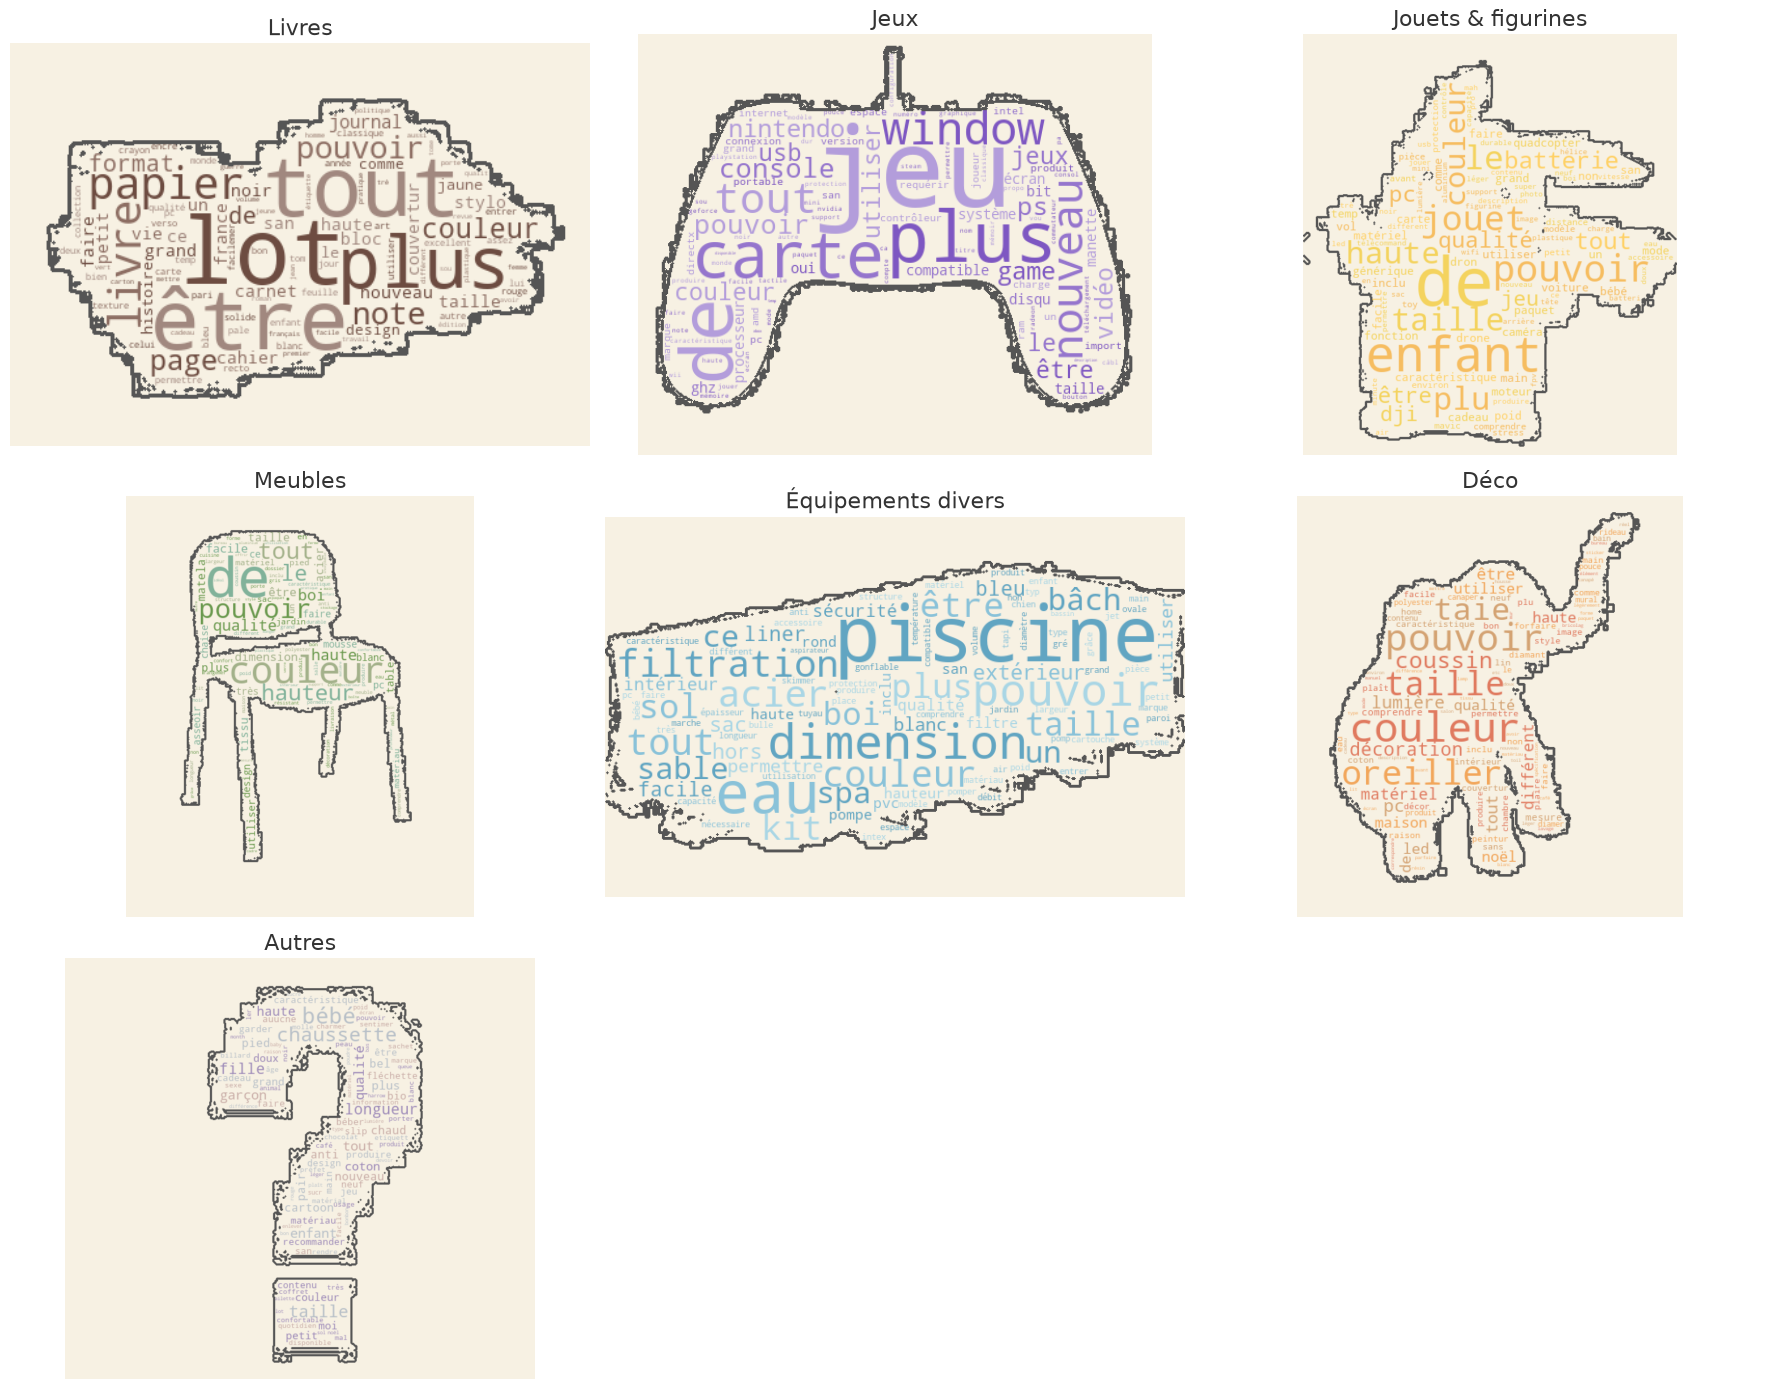

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from PIL import Image

# ------------------------------------------------------------
# Mapping familles -> fichiers de masque
# ------------------------------------------------------------
mask_files = {
    "Livres": "../images/livre.png",
    "Jeux": "../images/jeux.png",
    "Jouets & figurines": "../images/figurine.png",
    "Meubles": "../images/meuble.png",
    "Équipements divers": "../images/equipement.png",
    "Déco": "../images/deco.png",
    "Autres": "../images/autre.png"
}

familles = [
    "Livres",
    "Jeux",
    "Jouets & figurines",
    "Meubles",
    "Équipements divers",
    "Déco",
    "Autres"
]

# Dossier des masques
mask_dir = "."

# ------------------------------------------------------------
# Fond commun légèrement beige
# ------------------------------------------------------------
background_color = "#f7f1e3"

# ------------------------------------------------------------
# Couleurs douces par famille
# ------------------------------------------------------------
family_colors = {
    "Livres": ["#8d6e63", "#a1887f", "#6d4c41"],                 # brun doux
    "Jeux": ["#9575cd", "#7e57c2", "#b39ddb"],                   # violet doux
    "Jouets & figurines": ["#f4d35e", "#f6bd60", "#ffd166"],     # jaune
    "Meubles": ["#81b29a", "#6a994e", "#a3b18a"],                # vert doux
    "Équipements divers": ["#89c2d9", "#61a5c2", "#a9d6e5"],     # bleu
    "Déco": ["#e07a5f", "#f2a65a", "#d4a373"],                   # orange/terracotta
    "Autres": ["#9c89b8", "#c9ada7", "#b8c0c8"]                  # tons doux neutres
}

def make_color_func(colors):
    def color_func(*args, **kwargs):
        return np.random.choice(colors)
    return color_func

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(18, 14)
)

axes = axes.flatten()

for ax, famille in zip(axes, familles):
    texte_famille = " ".join(
        df.loc[df["famille_produit"] == famille, "texte_lemmatise"]
        .dropna()
        .astype(str)
    )

    mask_path = os.path.join(mask_dir, mask_files[famille])
    mask = np.array(Image.open(mask_path))

    wordcloud = WordCloud(
        width=900,
        height=500,
        background_color=background_color,
        mask=mask,
        contour_width=1.5,
        contour_color="#555555",
        max_words=100,
        collocations=False,
        regexp=r"\b\w{2,}\b"
    ).generate(texte_famille)

    wordcloud = wordcloud.recolor(
        color_func=make_color_func(family_colors[famille])
    )

    ax.imshow(wordcloud, interpolation="bilinear")
    ax.set_title(famille, fontsize=16, color="#333333")
    ax.axis("off")

# Masquer les axes inutilisés
for ax in axes[len(familles):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Vectorisation

In [97]:


X_text = df["texte_lemmatise"]
y = df["prdtypecode"]

# ------------------------------------------------------------
# Split train / validation
# ------------------------------------------------------------

X_train_text, X_val_text, y_train, y_val = train_test_split(X_text, y, test_size=0.2, random_state=42, stratify=y)

# ------------------------------------------------------------
# Vectorisation TF-IDF
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    max_features=50_000,     # limite la taille du vocabulaire
    ngram_range=(1, 2),      # unigrams + bigrams
    min_df=2,                # ignore les mots présents dans moins de 2 documents
    max_df=0.95,             # ignore les mots présents dans plus de 95% des documents
    sublinear_tf=True        # réduit l'impact des mots très répétés dans un même texte
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)

print("Shape train TF-IDF :", X_train_tfidf.shape)
print("Shape validation TF-IDF :", X_val_tfidf.shape)
print("Nombre de features TF-IDF :", len(tfidf.get_feature_names_out()))

Shape train TF-IDF : (67929, 50000)
Shape validation TF-IDF : (16983, 50000)
Nombre de features TF-IDF : 50000
